# Прогноз потребления в МО и раннее обнаружение шоков

В этом ноутбуке мы проходим по решению шаг за шагом: от данных до найденных шоков. Задача — прогнозировать безналичные траты жителя в 2 190 муниципальных образованиях на 1, 3, 6 и 12 месяцев, обогнать Prophet и как можно раньше замечать структурные сдвиги.

Лёгкие расчёты идут прямо здесь. Тяжёлые — десятки моделей на скользящем окне и дообучение нейросетей — мы запускали заранее (`./run_all.sh`), а здесь читаем их результаты из `data/interim/`.

**План:** 1. Данные · 2. Главная находка · 3. Как проверяем · 4. Модели · 5. Нейросети на коротких рядах · 6. Шоки · 7. Новости · 8. Ключевая ставка · 9. Итоги

In [1]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, yaml, matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
FC = ROOT / "data/interim/forecasts"
need = ["data/interim/panel.parquet", "data/interim/forecasts/prophet.parquet", "data/interim/changepoint/panel_shocks.parquet"]
missing = [p for p in need if not (ROOT / p).exists()]
print("Проект:", ROOT); print("Нет предрассчитанных файлов:" if missing else "Все предрассчитанные результаты на месте.", missing or "")

Проект: /Users/pavel/Desktop/сбер
Все предрассчитанные результаты на месте. 


## 1. Данные
Главный файл — набор организаторов `consumption.parquet`. На каждый муниципалитет, месяц и категорию — одно число: сколько в среднем потратил по картам один житель.

In [2]:
from src.data.load import build_panel
panel, terr = build_panel()
print(f"Строк: {len(panel):,}; МО: {panel.territory_id.nunique():,}; месяцев: {panel.period.nunique()} ({panel.period.min():%Y-%m} … {panel.period.max():%Y-%m})")
print("Категории:", ", ".join(panel.category.unique()))
print("МО с полной историей (24 мес.):", int((terr.months == 24).sum()))
panel[panel.category == "Все категории"].value.describe().round(0).to_frame("руб. на жителя в месяц").T

Строк: 303,126; МО: 2,190; месяцев: 24 (2023-01 … 2024-12)
Категории: Все категории, Здоровье, Маркетплейсы, Общественное питание, Продовольствие, Транспорт
МО с полной историей (24 мес.): 2016


,count,mean,std,min,25%,50%,75%,max
руб. на жителя в месяц,50521.0,28566.0,10737.0,11772.0,20813.0,25029.0,33563.0,91003.0


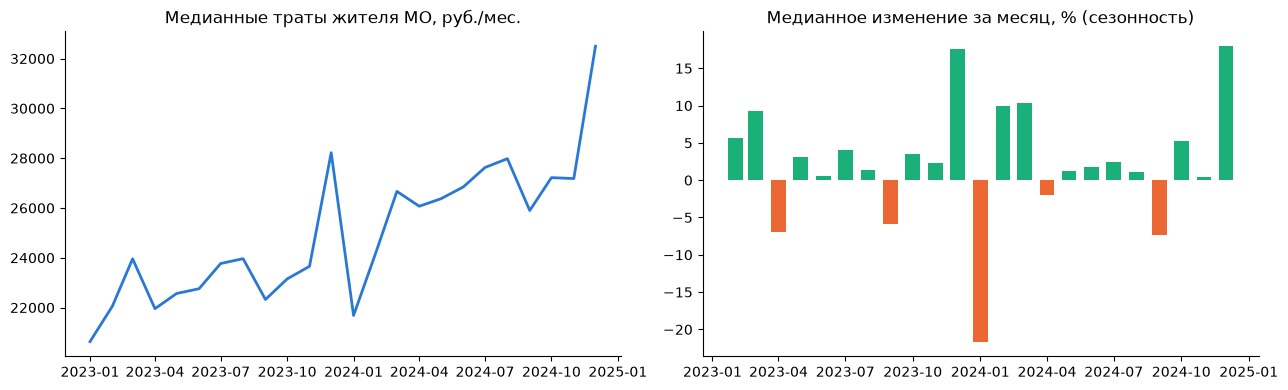

In [3]:
from src.eval.cv import load_wide
Y = load_wide(yaml.safe_load(open("configs/eval.yaml")))
ref = pd.read_parquet("data/external/territory_reference.parquet").set_index("territory_id")
med = Y.median(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(Y.index, med, lw=2, color="#2a78d6"); ax[0].set_title("Медианные траты жителя МО, руб./мес.")
mm = (Y.pct_change().median(axis=1) * 100).iloc[1:]
ax[1].bar(mm.index, mm.values, width=20, color=np.where(mm.values > 0, "#1baf7a", "#eb6834")); ax[1].set_title("Медианное изменение за месяц, % (сезонность)")
plt.tight_layout(); plt.show()

## 2. Главная находка: траты МО движутся вместе со страной
На графиках выше видно, что почти все муниципалитеты живут в одном ритме: в декабре траты взлетают, в январе проваливаются, а год к году растут примерно на 15 %. Своя динамика у МО — это проценты поверх общей.

Отсюда простая и сильная модель — **сезонная наивная модель с дрейфом**: берём тот же месяц год назад и умножаем на рост трат по России за последний известный год. Рост берём именно по стране: у муниципалитета 12–23 месяца истории, и свой годовой рост по ним не посчитать, а ряд России идёт с 2018 года.

,значение
"Майкоп, декабрь 2023","31,414"
рост трат России за год,×1.178
прогноз на декабрь 2024,"36,996"
факт,"36,320"
ошибка,+1.9 %


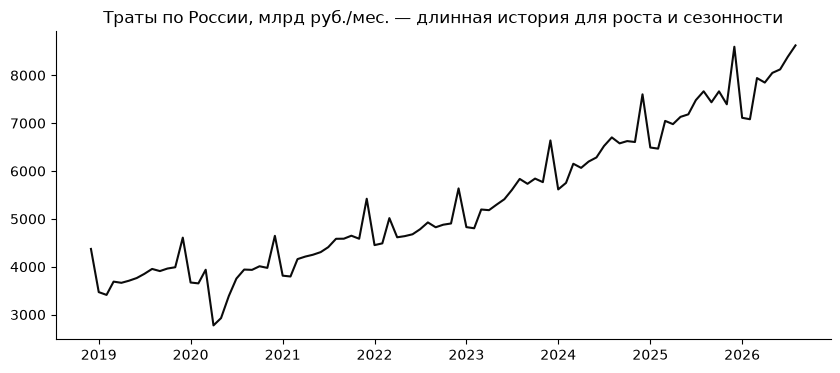

In [4]:
from src.forecast.lgbm_model import load_national
L = load_national(yaml.safe_load(open("configs/forecast.yaml")))
g = np.exp(L["2023-12-01"] - L["2022-12-01"])
mo = 1  # Майкоп
pred, fact = Y.loc["2023-12-01", mo] * g, Y.loc["2024-12-01", mo]
display(pd.DataFrame({"значение": [f"{Y.loc['2023-12-01', mo]:,.0f}", f"×{g:.3f}", f"{pred:,.0f}", f"{fact:,.0f}", f"{(pred/fact-1)*100:+.1f} %"]},
                     index=["Майкоп, декабрь 2023", "рост трат России за год", "прогноз на декабрь 2024", "факт", "ошибка"]))
fig, ax = plt.subplots(); ax.plot(np.exp(L), color="#0b0b0b"); ax.set_title("Траты по России, млрд руб./мес. — длинная история для роста и сезонности"); plt.show()

## 3. Как проверяем: скользящее окно
Модель в каждой точке прогноза видит только прошлое и прогнозирует 1, 3, 6 и 12 месяцев вперёд, потом мы сдвигаемся на месяц и повторяем. Ниже — то же самое вживую для двух простых моделей, а затем тест, который проверяет, что будущее в прогноз не попадает.

In [5]:
from src.eval.cv import run_cv
from src.eval.metrics import summarize
from src.forecast.baselines import SeasonalNaive, SeasonalNaiveNationalGrowth
cfg = yaml.safe_load(open("configs/eval.yaml"))
res = pd.concat([run_cv(Y, SeasonalNaive(), cfg), run_cv(Y, SeasonalNaiveNationalGrowth(), cfg)])
print("Точек прогноза по горизонтам:", res[res.model == "seasonal_naive"].groupby("h").origin.nunique().to_dict())
summarize(res).pivot(index="model", columns="h", values="MAE").round(0)

Точек прогноза по горизонтам: {1: 12, 3: 10, 6: 7, 12: 1}


h,1,3,6,12
model,,,,
seasonal_naive,4079.0,4345.0,4352.0,4704.0
snaive_natg,1250.0,1108.0,1143.0,1416.0


In [6]:
import subprocess
print(subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"], capture_output=True, text=True).stdout[-200:])

...                                                                      [100%]
3 passed in 0.18s



## 4. Модели прогноза
Все модели посчитаны на одних и тех же точках прогноза и муниципалитетах. Главная метрика — **MAE**, рублей на жителя в месяц. Дополнительно — R² по росту за год: угадывает ли модель, вырастут ли траты МО быстрее или медленнее среднего.

In [7]:
NAMES = {"prophet": "Prophet (базовая)", "seasonal_naive": "Сезонная наивная", "snaive_natg": "Сезонная наивная с дрейфом",
         "snaive_shrink_w25_k1": "+ shrinkage роста МО (w=0,25)*", "autoets": "AutoETS", "autotheta": "AutoTheta", "nhits": "N-HiTS",
         "lgbm_catmo": "LightGBM", "lgbm_resid": "+ LightGBM по остаткам", "chronos2_bc": "Chronos-2 zero-shot + backcasting",
         "timesfm_bc": "TimesFM zero-shot + backcasting", "tirex_bc_mix": "TiRex + форма года МО", "timesfm_lora": "TimesFM дообученный (LoRA)",
         "chronos2_ft_mix": "Chronos-2 дообученный + форма года МО", "ens_inv_mae": "Ансамбль (веса по обратной ошибке)"}
have = [m for m in NAMES if (FC / f"{m}.parquet").exists()]
allres = pd.concat(pd.read_parquet(FC / f"{m}.parquet") for m in have)
S = summarize(allres)
tab = S.pivot(index="model", columns="h", values="MAE").loc[have].rename(index=NAMES).round(0).astype(int)
tab.columns = [f"{h} мес." for h in tab.columns]
display(tab.style.highlight_min(axis=0, color="#d6e8fb"))
print("* вес w подобран на тех же данных — оценка оптимистичная")

,1 мес.,3 мес.,6 мес.,12 мес.
model,,,,
Prophet (базовая),1805,1755,2159,2901
Сезонная наивная,4079,4345,4352,4704
Сезонная наивная с дрейфом,1250,1108,1143,1416
"+ shrinkage роста МО (w=0,25)*",1060,1038,1095,1416
AutoETS,2070,2390,3169,6218
AutoTheta,1845,1854,2277,2960
N-HiTS,2894,1866,4446,1524
LightGBM,1216,1325,1552,4624
+ LightGBM по остаткам,1134,1441,1707,1416


* вес w подобран на тех же данных — оценка оптимистичная


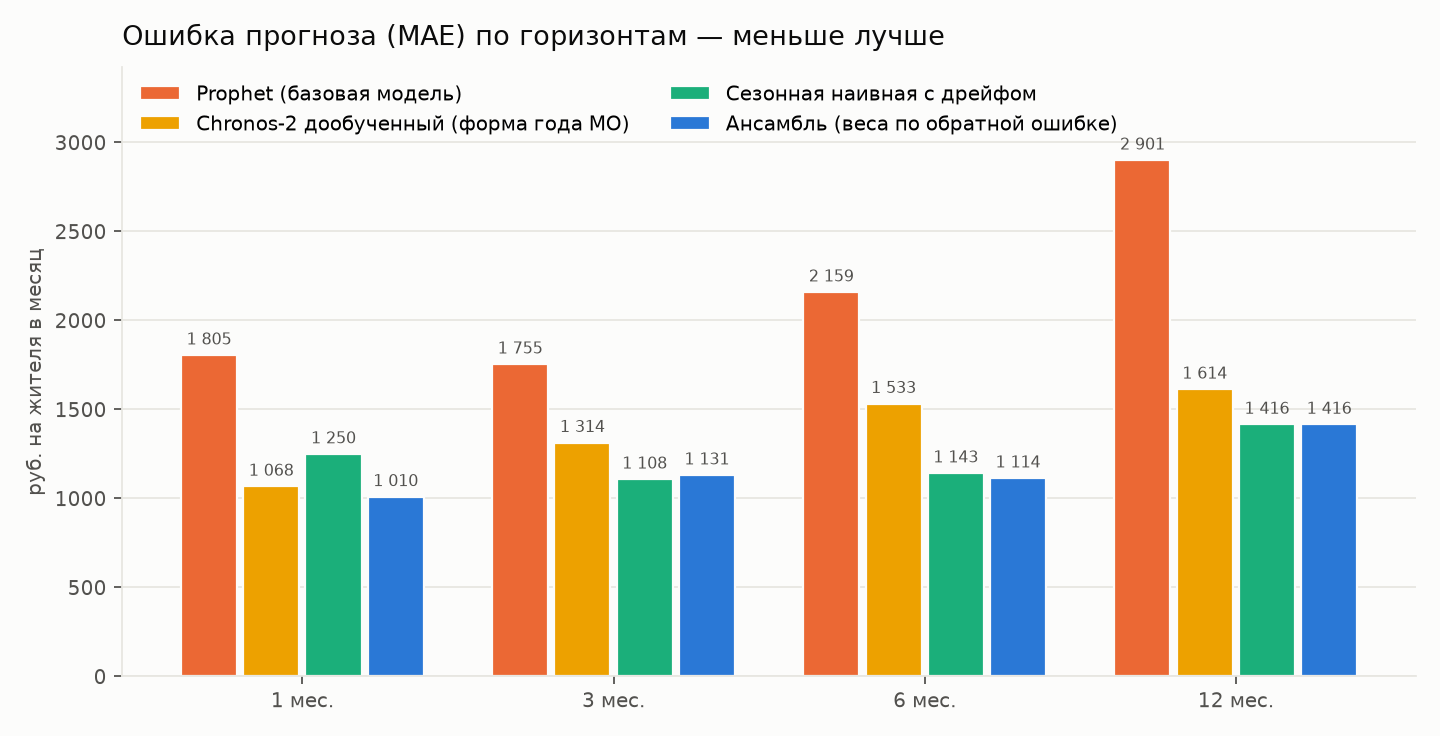

In [8]:
Image("report/figures/01_mae_by_horizon.png")

In [9]:
r2 = S[S.model.isin(["prophet", "snaive_natg", "chronos2_ft_mix", "ens_inv_mae"])].pivot(index="model", columns="h", values="R2_yoy").rename(index=NAMES).round(2)
r2.columns = [f"R² роста, {h} мес." for h in r2.columns]; r2

,"R² роста, 1 мес.","R² роста, 3 мес.","R² роста, 6 мес.","R² роста, 12 мес."
model,,,,
Chronos-2 дообученный + форма года МО,0.34,-0.15,-0.68,-0.61
Ансамбль (веса по обратной ошибке),0.27,0.00,-0.08,-0.44
Prophet (базовая),-0.84,-0.97,-2.17,-5.72
Сезонная наивная с дрейфом,-0.13,-0.03,-0.12,-0.44


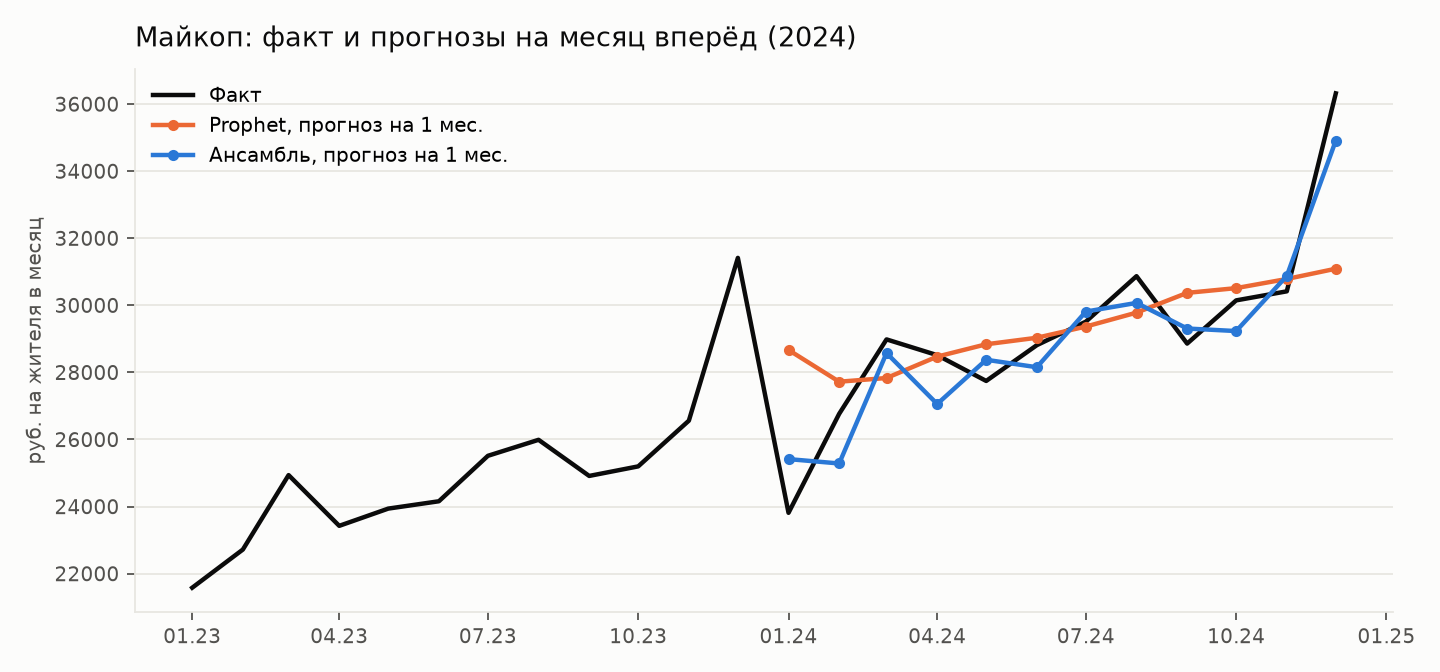

In [10]:
Image("report/figures/02_example_forecast.png")

**Значимы ли различия?** Тест Диболда–Мариано по точкам прогноза и доля муниципалитетов, где одна модель лучше другой. Точек немного (7–12), поэтому тест осторожный.

In [11]:
sig = pd.read_csv("data/interim/significance.csv")
sig["A"] = sig.A.map(NAMES).fillna(sig.A); sig["B"] = sig.B.map(NAMES).fillna(sig.B)
sig[sig.h < 12][["A", "B", "h", "разница_MAE", "p_DM", "доля_МО_где_A_лучше"]]

,A,B,h,разница_MAE,p_DM,доля_МО_где_A_лучше
0,Ансамбль (веса по обратной ошибке),Prophet (базовая),1,-795.7,0.023,0.986
1,Ансамбль (веса по обратной ошибке),Prophet (базовая),3,-623.2,0.178,0.935
2,Ансамбль (веса по обратной ошибке),Prophet (базовая),6,-1045.0,0.076,0.925
4,Сезонная наивная с дрейфом,Prophet (базовая),1,-555.4,0.132,0.788
5,Сезонная наивная с дрейфом,Prophet (базовая),3,-646.4,0.154,0.875
6,Сезонная наивная с дрейфом,Prophet (базовая),6,-1016.7,0.034,0.904
8,Chronos-2 дообученный + форма года МО,Prophet (базовая),1,-737.3,0.057,0.968
9,Chronos-2 дообученный + форма года МО,Prophet (базовая),3,-441.0,0.199,0.781
10,Chronos-2 дообученный + форма года МО,Prophet (базовая),6,-626.7,0.460,0.800
12,Ансамбль (веса по обратной ошибке),Сезонная наивная с дрейфом,1,-240.4,0.070,0.665


**Какую модель выбрать.** Сравниваем по нескольким критериям сразу: точность на каждом горизонте, стабильность, время, понятность. Смотрим, кто недоминируем (Парето), и агрегируем точность правилами Борда и Коупленда из теории выбора.

In [12]:
pd.read_csv("data/interim/selection_models.csv", index_col=0)

,MAE 1 мес.,MAE 3 мес.,MAE 6 мес.,MAE 12 мес.,разброс MAE по месяцам,"время, с",интерпретируемость,Парето (точность),Парето (все критерии),Борда (точность),Коупленд (точность)
Ансамбль (веса по обратной ошибке),1009.6,1131.3,1114.4,1416.1,496.1,900.0,3,True,True,7.5,8.0
Сезонная наивная с дрейфом,1250.0,1108.1,1142.8,1416.1,472.6,0.1,1,True,True,12.5,5.0
Chronos-2 дообученный,1068.1,1313.5,1532.8,1613.5,340.1,150.0,3,False,True,13.0,4.0
Сез. наивная + LightGBM по остаткам,1134.4,1440.5,1706.9,1416.1,465.5,15.0,2,True,True,17.0,1.0
TimesFM дообученный (LoRA),1118.9,1568.4,1673.3,2194.4,550.7,360.0,3,False,False,20.0,0.0
LightGBM,1216.0,1324.9,1552.3,4624.3,957.8,15.0,2,False,True,23.0,-1.0
TiRex,1008.0,1609.2,1944.0,3606.2,376.5,240.0,3,True,True,23.0,-3.0
Prophet,1805.3,1754.5,2159.5,2900.6,1348.6,20.0,2,False,False,30.0,-6.0
AutoTheta,1845.0,1854.4,2277.2,2960.3,1496.8,5.0,1,False,False,34.0,-8.0


Оба правила ставят первым ансамбль. Но на 3–12 месяцев он статистически не отличается от сезонной наивной модели с дрейфом, а та считается за доли секунды и объясняется одной фразой, — её мы и рекомендуем для практики. Дообученный Chronos-2 — лучшая нейросеть; интересно, где именно он полезен:

In [13]:
rows = []
for m in ["snaive_natg", "chronos2_ft_mix", "ens_inv_mae"]:
    f = pd.read_parquet(FC / f"{m}.parquet"); f["ae"] = (f.y_true - f.y_pred).abs()
    f["история"] = np.where(((f.origin.dt.year - 2023) * 12 + f.origin.dt.month) <= 17, "12–17 мес.", "18–23 мес.")
    rows.append(f[f.h == 1].groupby("история").ae.mean().rename(NAMES[m]))
pd.concat(rows, axis=1).round(0).astype(int).T.rename_axis("MAE на 1 мес. при истории")

история,12–17 мес.,18–23 мес.
MAE на 1 мес. при истории,,
Сезонная наивная с дрейфом,1493,1007
Chronos-2 дообученный + форма года МО,1064,1072
Ансамбль (веса по обратной ошибке),1195,824


Chronos-2 выигрывает в первой половине 2024 года — тогда рост трат страны резко замедлился, и правило «рост сохранится» ошиблось. Когда всё успокоилось, простая модель его догнала. Поэтому в ансамбле нейросеть — страховка на случай смены режима.

## 5. Нейросети на коротких рядах
Фундаментальным моделям 12–23 точек мало (TimesFM официально нужно не меньше 32). Мы восстановили прошлое каждого МО по ряду России (**backcasting**), учли собственную **форму года** муниципалитета и **дообучили** модели перед каждой точкой прогноза. Пример — Соболевский район Камчатки, где траты поднимаются в октябре, после лососёвой путины:

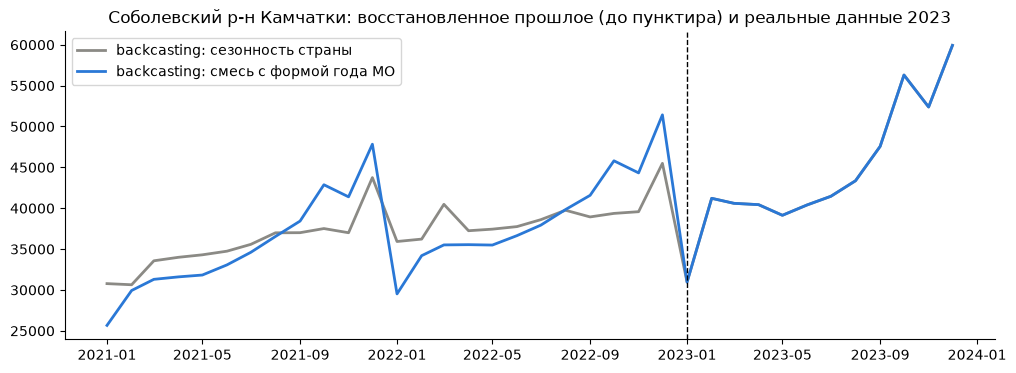

In [14]:
from src.forecast.foundation import _extend, _nat_level
nat = _nat_level(); tid = ref.index[ref.mo_name.str.contains("Соболевский")][0]
fig, ax = plt.subplots(figsize=(12, 4))
for mode, c in [("national", "#8b8a85"), ("mix", "#2a78d6")]:
    e = _extend(Y.iloc[:12][[tid]], nat, mode)
    ax.plot(e.index[-36:], e[tid].values[-36:], lw=2, color=c, label={"national": "backcasting: сезонность страны", "mix": "backcasting: смесь с формой года МО"}[mode])
ax.axvline(pd.Timestamp("2023-01-01"), color="k", ls="--", lw=1); ax.legend(); ax.set_title("Соболевский р-н Камчатки: восстановленное прошлое (до пунктира) и реальные данные 2023")
plt.show()

In [15]:
fm = ["timesfm", "timesfm_bc", "timesfm_bc_mix", "timesfm_lora", "chronos2", "chronos2_bc", "chronos2_ft", "chronos2_ft_mix", "tirex_bc", "tirex_bc_mix", "prophet"]
fm = [m for m in fm if (FC / f"{m}.parquet").exists()]
t = summarize(pd.concat(pd.read_parquet(FC / f"{m}.parquet") for m in fm)).pivot(index="model", columns="h", values="MAE").loc[fm].round(0).astype(int)
t.columns = [f"{h} мес." for h in t.columns]; t

,1 мес.,3 мес.,6 мес.,12 мес.
model,,,,
timesfm,2045,2638,4067,9045
timesfm_bc,1486,1903,2432,4200
timesfm_bc_mix,1200,1808,2076,3777
timesfm_lora,1119,1568,1673,2194
chronos2,2146,2701,4022,9458
chronos2_bc,1613,2240,2736,5154
chronos2_ft,1413,1660,1860,2234
chronos2_ft_mix,1068,1314,1533,1614
tirex_bc,1335,1908,1997,3086


## 6. Обнаружение шоков
Мы сравнили шесть детекторов, все решают только по прошлому. Готовой разметки шоков нет, поэтому проверяли тремя способами: встраивали шоки известной величины в 400 реальных рядов МО (с одинаковой для всех долей ложных тревог — 10 %), смотрели на реальные кризисы России 2020 и 2022 годов и на реальные события в муниципалитетах 2024 года.

In [16]:
pd.read_csv("data/interim/selection_detectors.csv", index_col=0)

,пропуск шоков,"задержка, мес.",тревога до шока,реакция на выброс,лишние тревоги по России,Парето,Борда,Коупленд
detector,,,,,,,,
По остаткам прогноза,0.393,1.429,0.022,0.054,NaN,True,7.5,5.0
По остаткам скользящего среднего,0.533,1.147,0.045,0.134,15.0,True,12.0,2.0
PELT,0.535,0.869,0.062,0.622,2.0,True,14.0,0.0
CUSUM,0.868,1.975,0.022,0.065,34.0,False,15.5,-1.0
BOCPD,0.590,0.519,0.068,0.722,0.0,True,16.0,-2.0
Пейдж–Хинкли,0.727,1.707,0.072,0.122,39.0,False,19.0,-4.0


In [17]:
bench = pd.read_csv("data/interim/changepoint/benchmark_summary.csv", index_col=0)
bench.sort_values("доля_найденных", ascending=False).round(3)

,доля_найденных,задержка_мес,тревога_до_шока,реакция_на_выброс
detector,,,,
base_residual,0.607,1.429,0.022,0.054
pelt_confirmed,0.480,1.545,0.058,0.674
forecast_residual,0.467,1.147,0.045,0.134
pelt,0.465,0.869,0.062,0.622
bocpd_confirmed,0.418,1.272,0.055,0.728
bocpd,0.410,0.519,0.068,0.722
page_hinkley,0.273,1.707,0.072,0.122
cusum,0.132,1.975,0.022,0.065


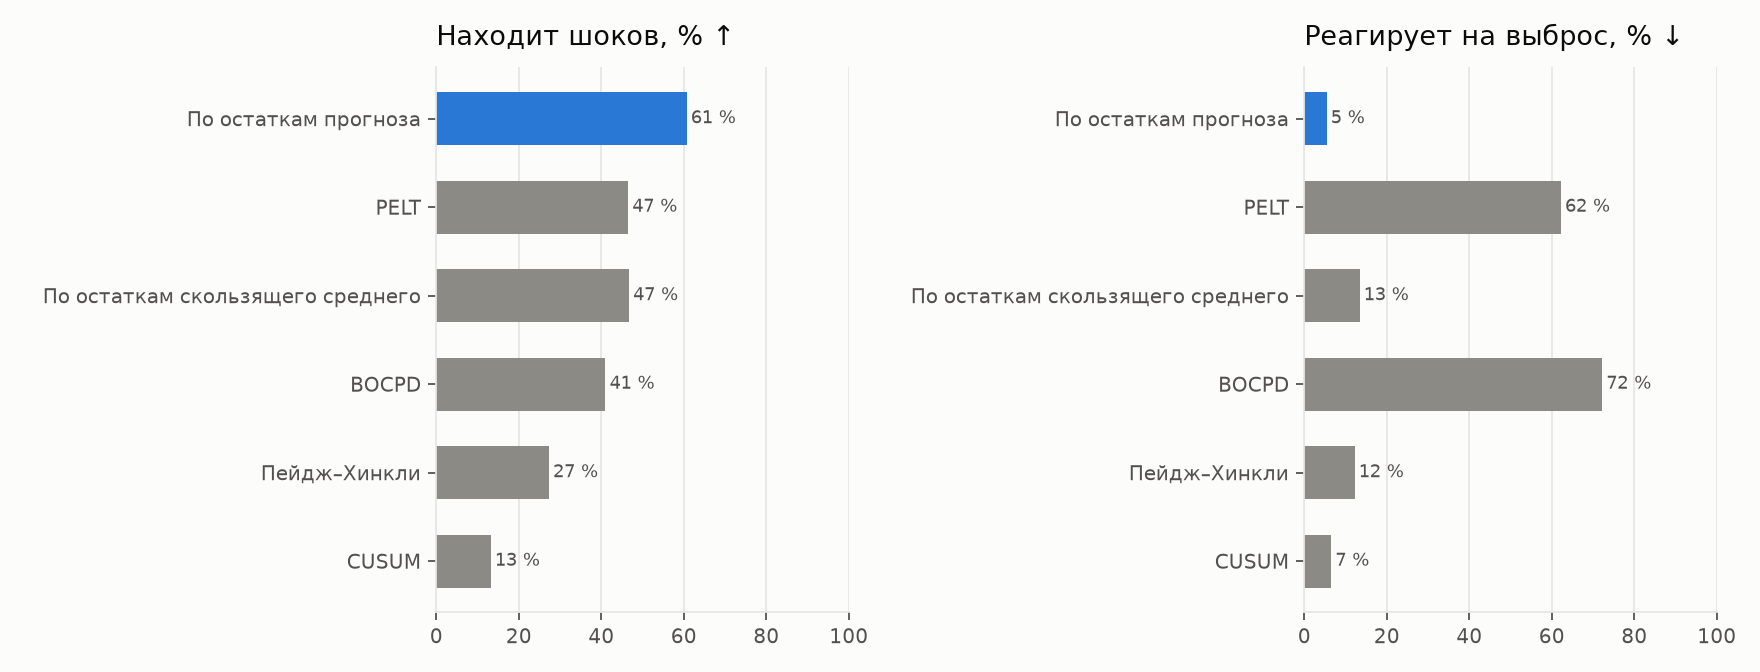

In [18]:
Image("report/figures/03_detectors.png")

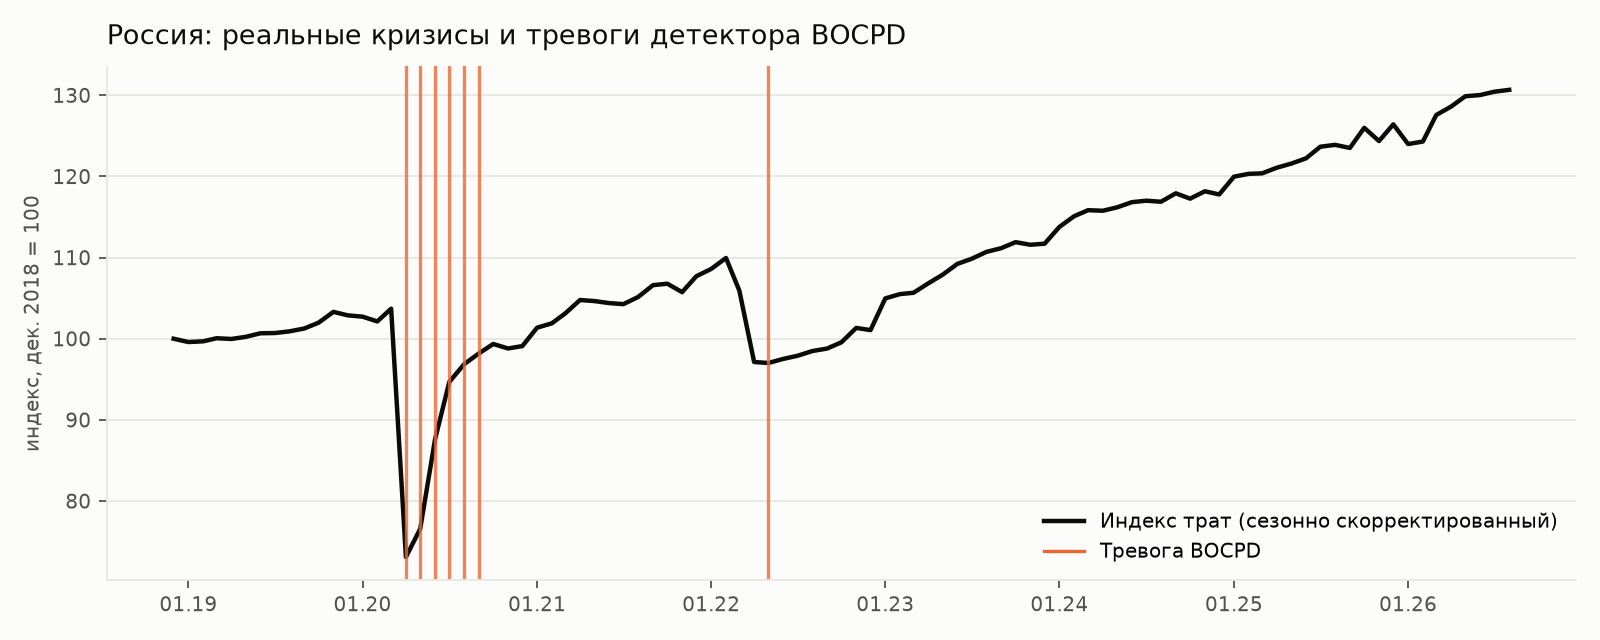

In [19]:
Image("report/figures/05_national_events.png")

In [20]:
sh = pd.read_parquet("data/interim/changepoint/panel_shocks.parquet")
best = sh[(sh.detector == "base_residual") & ~sh.seasonal & (sh.shift_pct.abs() >= 10)].copy()
best["МО"] = best.mo_name.str.replace("внутригородская территория города федерального значения", "").str[:40]
print(f"Шоков 2024 г. (лучший детектор, сдвиг ≥10 %, не сезонность): {len(best)} МО из {Y.shape[1]}")
best.sort_values("shift_pct", key=abs, ascending=False)[["МО", "region", "shift_month", "alarm", "shift_pct"]].head(10).round(1)

Шоков 2024 г. (лучший детектор, сдвиг ≥10 %, не сезонность): 22 МО из 2016


,МО,region,shift_month,alarm,shift_pct
99,Бай-Тайгинский муниципальный район,Республики Тывы,2024-10-01,2024-11-01,-21.7
62,Верхнеколымский муниципальный район,Республики Саха,2024-09-01,2024-10-01,-19.9
325,городской округ город Волгореченск,Костромской области,2024-06-01,2024-06-01,-19.4
107,Чеди-Хольский муниципальный район,Республики Тывы,2024-03-01,2024-04-01,17.4
55,Старошайговский муниципальный район,Республики Мордовии,2024-03-01,2024-05-01,17.2
469,городской округ Анивский,Сахалинской области,2024-05-01,2024-06-01,-14.8
241,Городищенский муниципальный район,None,2024-09-01,2024-11-01,13.6
505,городской округ Гаринский,Свердловской области,2024-01-01,2024-04-01,-12.2
223,городской округ город Коряжма,Архангельской области,2024-05-01,2024-05-01,-12.0
25,Сарпинский муниципальный район,Республики Калмыкии,2024-11-01,2024-12-01,-11.7


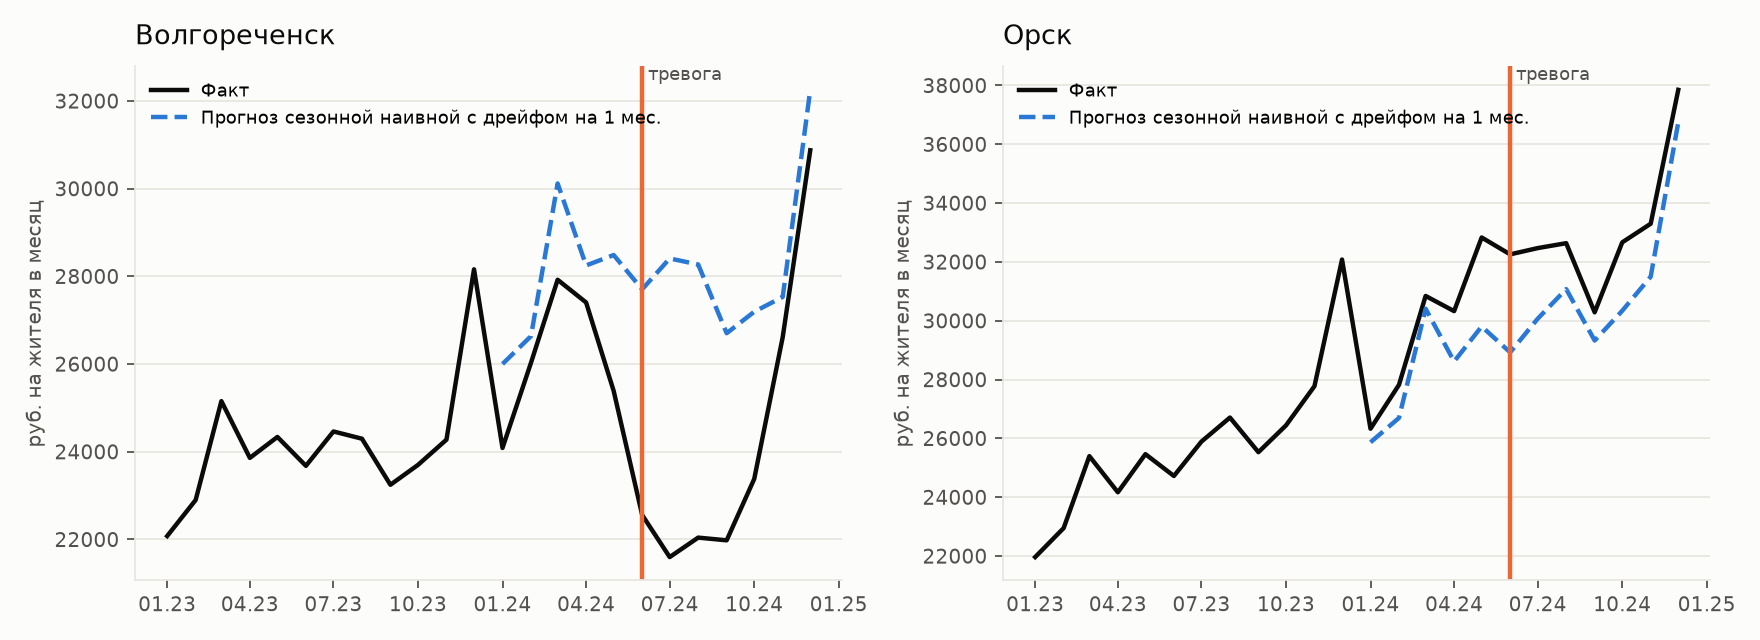

In [21]:
Image("report/figures/04_shock_examples.png")

## 7. Новости
Новость — это момент и место в тексте, а данные СберИндекса — месяц и код муниципалитета. Согласуем их в три шага: **время** (новость относится к месяцу публикации, прогноз видит только новости до своего момента), **место** (город в заголовке → МО и регион, с учётом падежей), **частота** (поток новостей → месячные доли тем). Источники — Lenta.ru, ИА REGNUM и МЧС России.

In [22]:
# сами заголовки в репозиторий не входят (чужие тексты), их собирает ./run_all.sh --heavy
hp = Path("data/external/news/headlines_tagged.parquet")
if hp.exists():
    h = pd.read_parquet(hp); print(f"Заголовков: {len(h):,}"); display(h.groupby("source").agg(заголовков=("title", "size"), с_регионом=("is_national", lambda s: f"{(~s).mean():.0%}")))
from src.news.geo import build_gazetteer, tag
gaz = build_gazetteer(ref)
ex = pd.Series(["В Орске эвакуировали жителей из-за прорыва дамбы", "В Туве ввели режим ЧС", "Жители Волгореченска пожаловались на закрытие ГРЭС"])
mo_ids, regs = tag(ex, gaz)
pd.DataFrame({"заголовок": ex, "МО": [[ref.mo_name.get(i, i) for i in x] for x in mo_ids], "регион": regs})

Заголовков: 277,069


,заголовков,с_регионом
source,,
lenta,103163,14%
mchs,2417,22%
regnum,171489,14%


,заголовок,МО,регион
0,В Орске эвакуировали жителей из-за прорыва дамбы,[городской округ город Орск],[Оренбургской области]
1,В Туве ввели режим ЧС,[],[Республики Тывы]
2,Жители Волгореченска пожаловались на закрытие ГРЭС,[городской округ город Волгореченск],[Костромской области]


**Как размечали «крупные события».** Сначала словарь ключевых слов, потом классификатор на эмбеддингах rubert-tiny2 (находит похожие по смыслу заголовки без слов из словаря), потом языковая модель Qwen3-1.7B проверяет кандидатов. Качество оценили на выборке из 200 заголовков, размеченных вручную:

In [23]:
q = Path("data/annotation/labeling_quality.csv")
pd.read_csv(q) if q.exists() else print("оценка качества ещё не посчитана: python -m src.news.annotation score")

,способ,точность,полнота,F1
0,словарь,0.766667,0.409638,0.533970
1,словарь или rubert-tiny2,0.201531,1.000000,0.335457
2,(словарь или rubert) и Qwen,0.823862,0.553431,0.662097


**Правило масштаба и длительности.** Первая версия инструкции для Qwen пропускала много мелочей — отключение горячей воды, ДТП, пожар в посёлке. Когда мы вручную проверяли выборку, договорились: крупное событие затрагивает больше ~100 человек и длится дольше нескольких дней. Перекрытая на сутки дорога или остановка транспорта на день-два на траты за месяц не влияют (при дневных данных о продажах — наоборот, могли бы помочь). Это правило мы добавили в инструкцию модели и перепроверили все её прошлые «Да». Вот сама инструкция и примеры:

In [24]:
from src.news import llm_verify
print(llm_verify.SYSTEM, "\n")
pd.DataFrame(llm_verify.SHOTS, columns=["пример заголовка", "ответ"])

Ты аналитик региональной экономики России. По заголовку новости определи, сообщает ли он о КРУПНОМ событии на конкретной территории России, которое может заметно изменить траты её жителей: стихийное бедствие (паводок, наводнение, прорыв дамбы, крупный природный пожар, землетрясение), введённый режим ЧС, массовая эвакуация, масштабная авария с отключением света или тепла, закрытие или остановка крупного предприятия, массовые увольнения. Событие должно затрагивать больше ста человек и длиться дольше нескольких дней — данные о тратах месячные, и событие на день-два на них не скажется. НЕ считаются: рядовые и локальные происшествия (пожар в доме или посёлке, ДТП, обрушение одного дома, авария с цистерной, отдельные пострадавшие), перекрытие дороги или остановка транспорта на день-два, совещания, учения, прогнозы и подготовка, события за пределами России, военные новости без последствий для жителей. Ответь одним словом: Да или Нет. 



,пример заголовка,ответ
0,"В Орске прорвало дамбу, затоплены тысячи домов",Да
1,"Пожар в частном доме в Твери, погиб мужчина",Нет
2,В Туве ввели режим ЧС после взрыва на ТЭЦ,Да
3,Губернатор провёл совещание по подготовке к паводку,Нет
4,"В Челябинской области останавливают металлургический завод, сотни уволены",Да
5,На Филиппинах эвакуировали тысячи жителей из-за вулкана,Нет
6,Минобороны сообщило о перехвате снарядов РСЗО «Ураган»,Нет
7,Из-за снегопада в Самарской области на сутки перекрыли трассу,Нет
8,"В Приамурье из-за паводка эвакуировали жителей трёх сёл, подтоплены сотни домов",Да


In [25]:
llm = pd.read_parquet("data/external/news/major_llm.parquet")
v1 = Path("data/interim/major_llm_v1.parquet")   # разметка до строгого правила (сохраняется при перепроверке)
print(f"Кандидатов от словаря и rubert-tiny2: {len(llm):,}")
if v1.exists():
    old = pd.read_parquet(v1)
    print(f"Qwen, первая инструкция: «Да» у {int(old.llm_major.sum()):,}")
print(f"Qwen, строгое правило: «Да» у {int(llm.llm_major.sum()):,}")
if hp.exists() and v1.exists():
    t = h[["url", "title"]].merge(old[["url", "llm_major"]].rename(columns={"llm_major": "было"}), on="url").merge(llm[["url", "llm_major"]].rename(columns={"llm_major": "стало"}), on="url")
    print("\nСнято строгим правилом:"); display(t[t.было & ~t.стало].sample(8, random_state=1)[["title"]])
    print("Осталось крупным событием:"); display(t[t.стало].sample(8, random_state=1)[["title"]])

Кандидатов от словаря и rubert-tiny2: 4,987


Qwen, первая инструкция: «Да» у 2,343
Qwen, строгое правило: «Да» у 611

Снято строгим правилом:


,title
2139,В Москве после сообщений о минировании эвакуировали шесть судов
4748,Под Мурманском началась эвакуация пострадавших при столкновении поездов
3629,После взрыва на мосту под Самарой частично восстановили движение поездов
3286,В Мурманской области из-за наплыва мигрантов поставили дополнительные КПП
4488,Пожарные ликвидировали открытое горение на складе в Подмосковье
3395,Белгородский губернатор сообщил об обстреле села Графовка
1898,Стало известно о пострадавших при пожаре на нефтебазе в Крыму
4091,В переживающей мусорный коллапс Псковской области начали вывозить отходы


Осталось крупным событием:


,title
707,Стало известно о погибших в результате ЧП на Крымском мосту
2435,Городские службы Москвы отработали безаварийный пропуск паводка
1899,Площадь пожара на нефтебазе в Крыму возросла
4904,"Камчатские спасатели эвакуировали людей, терпящих бедствие на воде - условно"
1904,В МЧС сообщили подробности о ситуации с горящей третьи сутки нефтебазой в Крыму
3936,Уровень реки Урал у Оренбурга за сутки поднялся на 28 сантиметров
3932,Мэрия Орска сообщила о четырёх погибших в подтопленном городе
3985,Вода подтопила Старый город в Орске без захода на другие районы


Модель не безупречна: среди оставленных попадаются учения («условно») и новости о том, что паводок прошёл без происшествий. Поэтому точность каскада на ручной выборке — 0,82, а не 1. Для объяснения шоков этого достаточно: аналитик всё равно смотрит на заголовки сам.

**Помогают ли новости находить шоки?** Смотрим, как ведут себя траты муниципалитетов до и после крупного события — по сравнению со случайными МО:

In [26]:
me = pd.read_pickle("data/interim/major_events.pkl")
pd.DataFrame({k: {"событий": v["n"], "после − до": round(v["delta"], 2), "у случайных МО": round(v["null"], 2), "p": round(v["p"], 3)} for k, v in me["res"].items()}).T

,событий,после − до,у случайных МО,p
все крупные события,767.0,0.04,0.05,0.763
названные в новостях города,17.0,0.01,0.05,0.591
все МО региона события,750.0,0.04,0.05,0.752
по событиям,29.0,0.10,0.04,0.220


Для словаря и для нейросетевой разметки посчитано по-разному: по каждому МО отдельно и по событиям целиком (регион-месяц), иначе событие в Москве весит как 143 паводка. Разница «после − до» в ожидаемую сторону есть, но незначима: систематической связи «крупное событие → сдвиг месячных трат» на этих данных мы не нашли. График ниже — профиль расхождения по месяцам вокруг события:

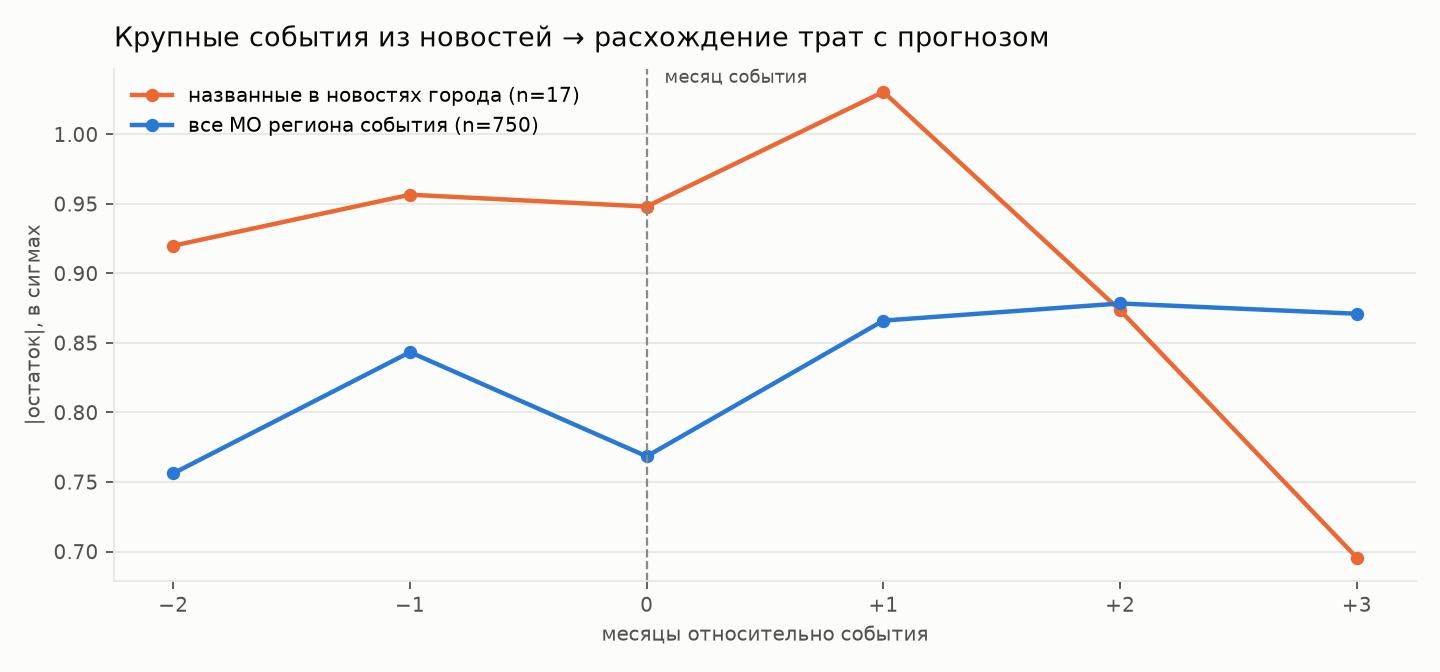

In [27]:
Image("report/figures/07_event_study.png")

Зато в отдельных случаях новости хорошо объясняют, что произошло. Орск: прорыв дамбы в апреле 2024 года, а в мае–июне траты заметно выше прогноза. Поэтому новости мы используем так: детектор становится чувствительнее в регионе после крупного события, а к каждой тревоге подбираются новости.

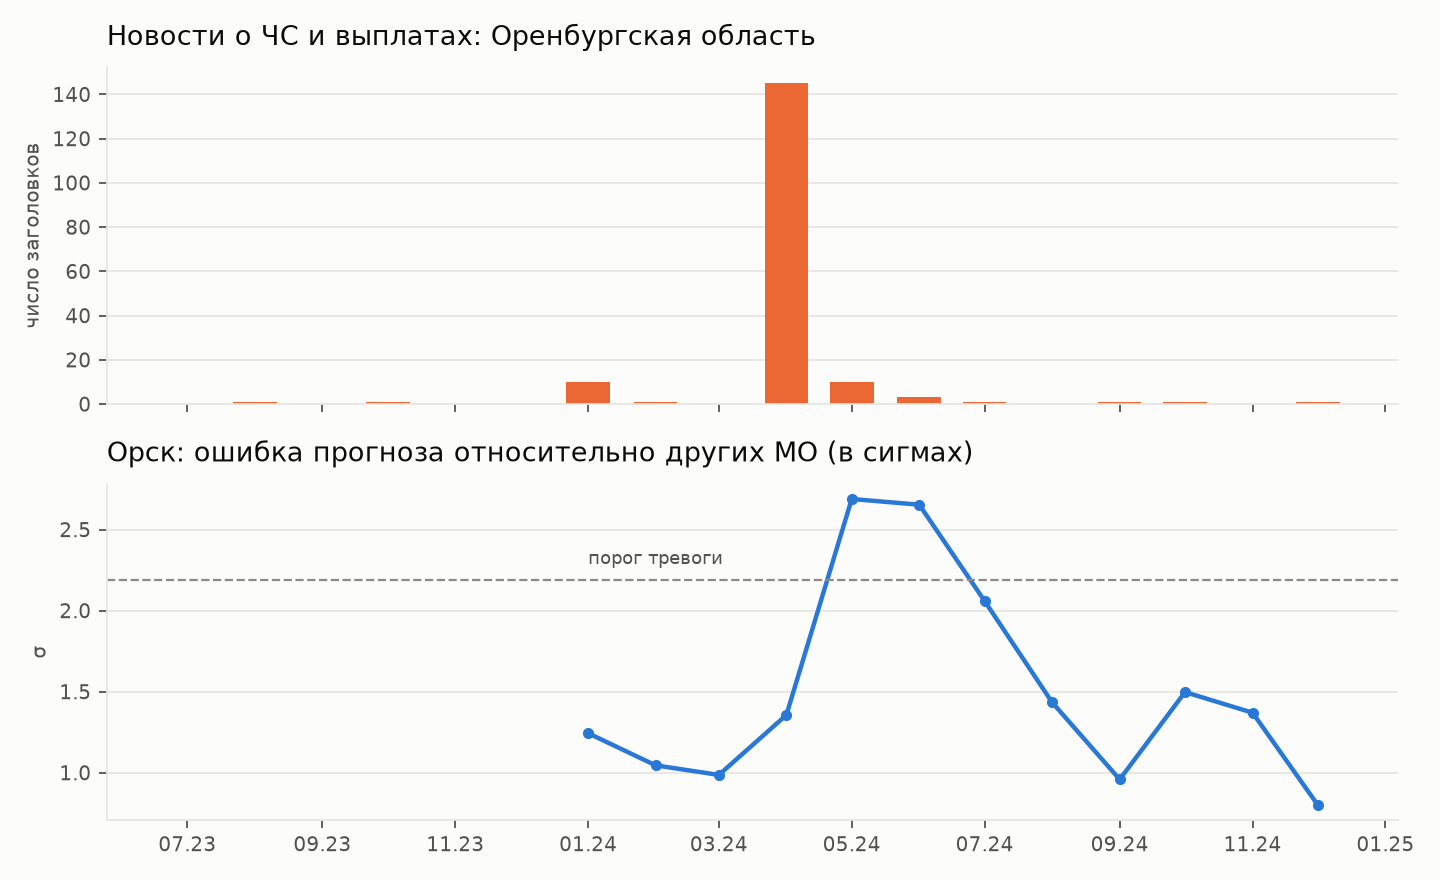

In [28]:
Image("report/figures/06_news_case_orsk.png")

In [29]:
ni = pd.read_pickle("data/interim/changepoint/news_informed.pkl")
al = ni["alarms"].pivot(index="territory_id", columns="режим", values="alarm")
print(f"Порог обычный {ni['thr']:.2f}, после новости о крупном событии в регионе — {ni['thr_low']:.2f}")
print("Тревог всего:", al.notna().sum().to_dict())
o = ni["events_eval"]
o.pivot_table(index="named", columns="режим", values="найден", aggfunc="mean").rename(index={True: "МО, названные в новостях", False: "все МО региона события"}).round(3)

Порог обычный 2.19, после новости о крупном событии в регионе — 1.51
Тревог всего: {'обычный': 193, 'с новостями': 258}


режим,обычный,с новостями
named,,
все МО региона события,0.040,0.087
"МО, названные в новостях",0.136,0.182


In [30]:
print(open("report/shock_cards.md", encoding="utf-8").read()[:3000])

# Карточки шоков: что говорили новости

Шоки, найденные лучшим детектором (по остаткам прогноза) в 2024 году, сдвиг ≥ 5 %, без собственной сезонности МО. Для каждого — новости значимых тем (ЧС, закрытие/открытие производств, выплаты) о МО и его регионе за 2 месяца до начала сдвига и до месяца после тревоги. «Опережение» — на сколько месяцев первая такая новость вышла раньше тревоги детектора. «Крупное событие» — заголовок из узкого словаря (паводки, режим ЧС, эвакуации, закрытие предприятий); такие новости показаны первыми. Подбор по ключевым словам ошибается (например, «выплата» в новости о знаменитости), поэтому карточка — кандидаты в объяснение, а не доказательство. Новости из федерального источника (Lenta.ru); отсутствие новостей не значит, что причины не было.

## Бай-Тайгинский муниципальный район (Республики Тывы)

Сдвиг трат **-22 %** с 10.2024, тревога детектора в 11.2024. Новостей о МО: 0, о регионе: 3. Первая новость: 3 мес. до тревоги.

| Дата | О чём | Крупное событие | За

## 8. Ключевая ставка
Ставка одна для всей страны, поэтому различий между муниципалитетами она не объясняет. Мы проверили её там, где она может помочь, — в прогнозе роста трат России, на ряде с 2018 года:

In [31]:
kr = pd.read_parquet("data/interim/key_rate_check.parquet")
kr.pivot_table(index="метод", columns="h", values="err").round(2).rename_axis("ошибка прогноза годового роста, п.п.")

h,1,3,6,12
"ошибка прогноза годового роста, п.п.",,,,
"+ ставка, окно 12 мес.",1.71,2.72,4.21,4.97
"+ ставка, окно 3 мес.",1.66,3.02,4.26,5.00
"+ ставка, окно 6 мес.",1.65,2.70,3.86,5.11
рост сохранится,1.45,2.24,3.31,4.93


## 9. Итоги
Общая динамика страны объясняет почти всё движение трат в муниципалитетах, и на ней построен прогноз, который на 36–51 % точнее Prophet. Нейросети на коротких рядах заработали после backcasting, учёта формы года и дообучения. Шоки лучше всего находит детектор по остаткам прогноза — он почти не путает их с разовыми выбросами. Новости привязаны к данным по времени и месту и помогают объяснять найденные сдвиги.

Подробнее — в [отчёте](../report/REPORT.md) и [презентации](../presentation/presentation.pdf).